# REFMAP laboratory listening test 2 analysis: Effect size estimation analysis

## Setup

In [1]:
# import packages
import sys
import os
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import QFileDialog, QApplication
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D
import seaborn as sns
import dabest
import warnings
import pingouin as pg
from refmap_psychoacoustics.utils.format_helpers import (round_trad, display_round)

# Suppress FutureWarning messages to quiet pandas
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:13<00:00,  1.21s/it]


Numba compilation complete!


In [2]:
# set plot parameters
sns.set_style('white')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams.update({'font.size': 16})
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['mathtext.fontset'] = 'stix'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE,
       labelsize=MEDIUM_SIZE)    # fontsize of the axes title and x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

mycolours = [(0, 102, 255), (0, 204, 153), (255, 0, 102), (74, 111, 152),
             (251, 164, 49), (204, 153, 255), (90, 192, 255), (80, 245, 233),
             (255, 90, 192), (164, 201, 242), (255, 254, 139), (255, 243, 255)]
mycolours = [tuple(shade/255 for shade in colour) for colour in mycolours]

np.random.seed(303)

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True

# check/open QApplication instance
if not QApplication.instance():
    app = QApplication(sys.argv)
else:
    app = QApplication.instance() 

# setup ipython autoreloading magic
%load_ext autoreload
%autoreload 2

Set the saveplots toggle to True if plot saving is desired:

In [ ]:
saveplots = True

if saveplots:
    # select figure output save path
    outFigPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save plots in: 03 Experiment\Experiment 2\Analysis\Plots")

    # create subfolders if not already existing
    try:
        os.mkdir(os.path.join(outFigPath, "svg"))
    except FileExistsError:
        pass

    try:
        os.mkdir(os.path.join(outFigPath, "pdf"))
    except FileExistsError:
        pass


## Import data and organise

In [4]:
# import test data
fileExts = "*.csv"

dataBySubjFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_testdata_BySubj.csv",
                                                       caption=r"Open refmap_listest2_testdata_BySubj.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]
dataBySubjTest = pd.read_csv(dataBySubjFilePath)



In [16]:
# categorise columns

aam_attitude_cats = ["Neutral", "Supportive", "Ambivalent", "Concerned"]

for dataset in [dataBySubjTest]:
    dataset['UASProximity'] = pd.Categorical(dataset['UASProximity'], ["Baseline", "Far", "Near"])
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Residential", "Park (high)",
                                                                    "Highway (low)", "Streetside square",
                                                                    "Highway"])
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight", "Delivery"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "T150"])
    dataset['UASStart'] = pd.Categorical(dataset['UASStart'], ["Baseline", "Left", "Right"])   
    dataset['AAMAttitude'] = pd.Categorical(dataset['AAMAttitude'], aam_attitude_cats)


In [6]:
# arrange compiled categories for personal factors

dataBySubjTest.loc[dataBySubjTest['Nationality'] == "NotAnswered", 'Nationality'] = "Unanswered"
dataBySubjTest.loc[dataBySubjTest['NationGeo'] == "NotAnswered", 'NationGeo'] = "Unanswered"
dataBySubjTest.loc[dataBySubjTest['UKNational'] == "NotAnswered", 'UKNational'] = "Unanswered"

dataBySubjTest['NationGeo2'] = dataBySubjTest['NationGeo']
dataBySubjTest.loc[(dataBySubjTest['NationGeo'] != 'Unanswered')
                      & (dataBySubjTest['NationGeo'] != 'UK'), 'NationGeo2'] = "Other"

dataBySubjTest['NationGeo3'] = dataBySubjTest['NationGeo']
dataBySubjTest.loc[(dataBySubjTest['NationGeo'] == 'Africa')
                      | (dataBySubjTest['NationGeo'] == 'SouthAsia'), 'NationGeo3'] = "Africa_SAsia"
dataBySubjTest.loc[(dataBySubjTest['NationGeo3'] != 'Africa_SAsia')
                      & (dataBySubjTest['NationGeo3'] != 'UK'), 'NationGeo3'] = "Other"

dataBySubjTest['Home_Area2'] = dataBySubjTest['HomeArea']
dataBySubjTest.loc[(dataBySubjTest['Home_Area2'] == 'Suburban')
                      | (dataBySubjTest['Home_Area2'] == 'Rural'), 'Home_Area2'] = "Suburban_Rural"

dataBySubjTest['Area_soundscape2'] = dataBySubjTest['SoundscapeArea']
dataBySubjTest.loc[(dataBySubjTest['Area_soundscape2'] == 'Chaotic')
                      | (dataBySubjTest['Area_soundscape2'] == 'Vibrant'), 'Area_soundscape2'] = "Eventful"
dataBySubjTest.loc[(dataBySubjTest['Area_soundscape2'] == 'Monotonous')
                      | (dataBySubjTest['Area_soundscape2'] == 'Calm'), 'Area_soundscape2'] = "Uneventful"

# deal with fragmentation
dataBySubjTestCopy = dataBySubjTest.copy()
dataBySubjTest =  dataBySubjTestCopy.copy()
del dataBySubjTestCopy

C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\1591503677.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataBySubjTest['NationGeo2'] = dataBySubjTest['NationGeo']
C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\1591503677.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataBySubjTest['NationGeo3'] = dataBySubjTest['NationGeo']
C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\1591503677.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

## Setup output dataframes

In [7]:
out = pd.DataFrame()
outd = pd.DataFrame()

savedata = True

if savedata:
    # select data output save path
    outDataPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save output data in: \03 Experiment\Experiment 2\Analysis\Python")


## Ambient environments

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['AmbientEnv'] != "Highway (low)")
                       & (dataBySubjTest['AmbientEnv'] != "Park (high)")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# remove unused categories from categorical columns
data['AmbientEnv'] = data['AmbientEnv'].cat.remove_unused_categories()

# create dummy pairing ID for each participant to allow for paired analysis
grouping_cols = ['ID', 'UASOperation', 'UASProximity', 'UASType']

# ngroup() automatically assigns an identical integer to matching sets 
# across your different environment conditions
data['dummyID'] = data.groupby(grouping_cols).ngroup() + 1
data.sort_values(by=['dummyID', 'ID', 'StimID'], inplace=True)

# remove any dummyID pairs of rows with at least one missing value
data = data.groupby('dummyID').filter(lambda x: not x.isnull().any().any())


In [49]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=list(data['AmbientEnv'].cat.categories),
                         x='AmbientEnv', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\2984254566.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\2984254566.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_13856\2984254566.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Park,Residential,336,336,mean difference,baseline,0.181808,95,0.003459,0.384043,0.059788,5.194124e-01,27160.0,6.186253e-02,-1.873553
1,Park,Streetside square,336,336,mean difference,baseline,-1.755875,95,-1.995699,-1.520448,0.000200,4.179229e-33,6949.0,9.011659e-39,14.873151
2,Park,Highway,336,336,mean difference,baseline,-2.369062,95,-2.616751,-2.128431,0.000200,3.713321e-43,3766.0,2.405071e-55,19.052052


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


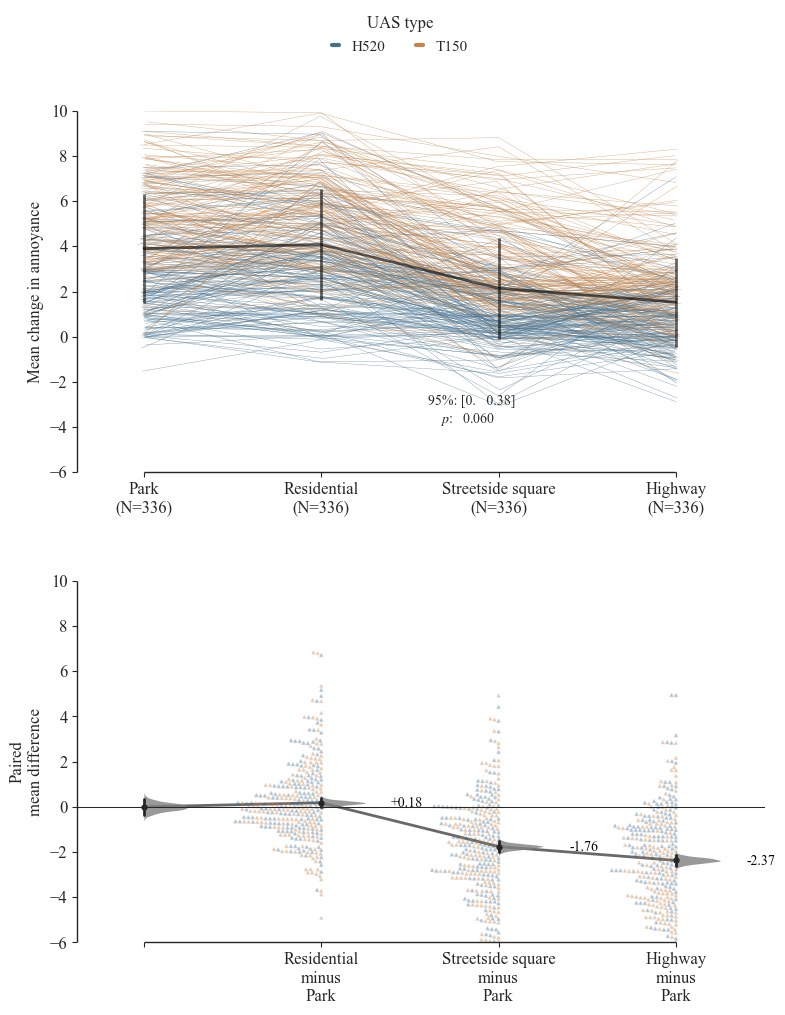

In [53]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(color_col='UASType',
                                   contrast_bars=False,
                                   raw_ylim=(-6, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [0.35, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'UAS type'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1},
                                   contrast_ylim=(-6, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)


lgd = axs[0].get_legend()
for lh in lgd.legend_handles:
    lh.set_alpha(1)
    lh.set_linewidth(3)

if saveplots:
    
    filename = "AmbEnvDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [35]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,672,672,Cohen's d,baseline,0.317858,95,0.270156,0.368772,0.0002,1.484741e-32,53250.0,3.224977e-33,-12.688112


### by ambient environment

#### Highway

In [51]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['AmbientEnv'] == "Highway")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# create dummy pairing ID for each participant to allow for paired analysis
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASProximity'].unique()) + 1, dtype=int),
                            len(data['UASProximity'].unique()), axis=0)

# remove any dummyID pairs of rows with at least one missing value
for dummyID in data['dummyID'].unique():
    if data[data['dummyID'] == dummyID].isnull().any(axis=None):
        data = data[data['dummyID'] != dummyID]

# remove unused categories from categorical columns
data['UASProximity'] = data['UASProximity'].cat.remove_unused_categories()

In [52]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Far", "Near"), x='UASProximity', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\dabest\plot_tools.py:2461: UserWarning: unique values in 'UASProximity' column in `data` and `palette` do not have the same length. Number of unique values is 1 while length of palette is 12. The assignment of the colors in the palette will be cycled.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,mean difference,baseline,0.631903,95,0.423104,0.838018,0.0002,5.180296e-08,3660.0,1.731615e-08,-5.925521


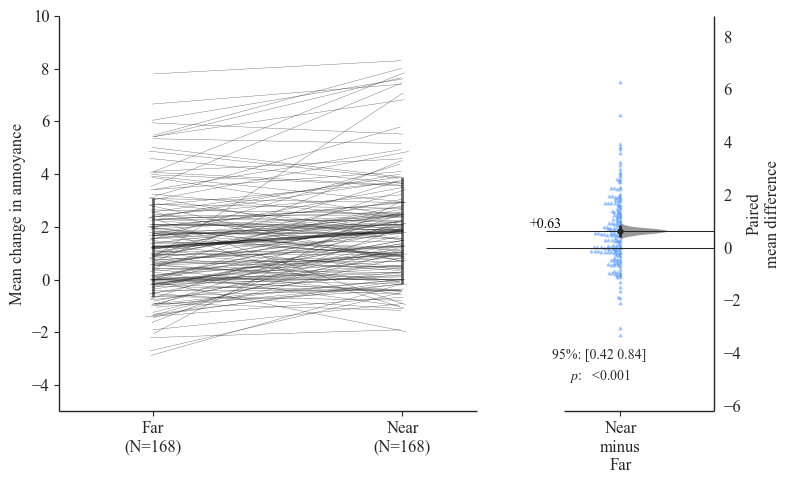

In [53]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False,
                                   raw_ylim=(-5, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [-1.75, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'Ambient env'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1,
                                                     'color': mycolours[0:]},
                                   contrast_ylim=(-5, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05,
                                                      'color': mycolours[0:]},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)

if saveplots:
    
    filename = "ProximityHighwayDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [54]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,Cohen's d,baseline,0.323807,95,0.216874,0.428625,0.0002,5.180296e-08,3660.0,1.731615e-08,-5.925521


#### Park

In [55]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['AmbientEnv'] == "Park")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# create dummy pairing ID for each participant to allow for paired analysis
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASProximity'].unique()) + 1, dtype=int),
                            len(data['UASProximity'].unique()), axis=0)

# remove any dummyID pairs of rows with at least one missing value
for dummyID in data['dummyID'].unique():
    if data[data['dummyID'] == dummyID].isnull().any(axis=None):
        data = data[data['dummyID'] != dummyID]

# remove unused categories from categorical columns
data['UASProximity'] = data['UASProximity'].cat.remove_unused_categories()

In [56]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Far", "Near"), x='UASProximity', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\dabest\plot_tools.py:2461: UserWarning: unique values in 'UASProximity' column in `data` and `palette` do not have the same length. Number of unique values is 1 while length of palette is 11. The assignment of the colors in the palette will be cycled.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,mean difference,baseline,0.705499,95,0.47004,0.982046,0.0002,5.134402e-08,3659.0,1.997214e-07,-5.425985


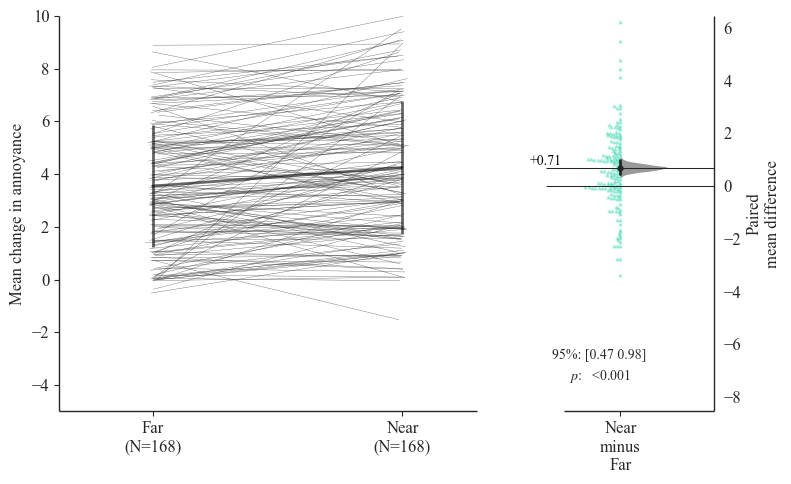

In [57]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False,
                                   raw_ylim=(-5, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [-1.75, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'Ambient env'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1,
                                                     'color': mycolours[1:]},
                                   contrast_ylim=(-5, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05,
                                                      'color': mycolours[1:]},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)

if saveplots:
    
    filename = "ProximityParkDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [58]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,Cohen's d,baseline,0.293307,95,0.193174,0.405751,0.0002,5.134402e-08,3659.0,1.997214e-07,-5.425985


#### Residential

In [62]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['AmbientEnv'] == "Residential")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# create dummy pairing ID for each participant to allow for paired analysis
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASProximity'].unique()) + 1, dtype=int),
                            len(data['UASProximity'].unique()), axis=0)

# remove any dummyID pairs of rows with at least one missing value
for dummyID in data['dummyID'].unique():
    if data[data['dummyID'] == dummyID].isnull().any(axis=None):
        data = data[data['dummyID'] != dummyID]

# remove unused categories from categorical columns
data['UASProximity'] = data['UASProximity'].cat.remove_unused_categories()

In [63]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Far", "Near"), x='UASProximity', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\dabest\plot_tools.py:2461: UserWarning: unique values in 'UASProximity' column in `data` and `palette` do not have the same length. Number of unique values is 1 while length of palette is 10. The assignment of the colors in the palette will be cycled.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,mean difference,baseline,1.059456,95,0.800334,1.323119,0.0002,1.037860e-12,2599.0,6.685387e-13,-7.791853


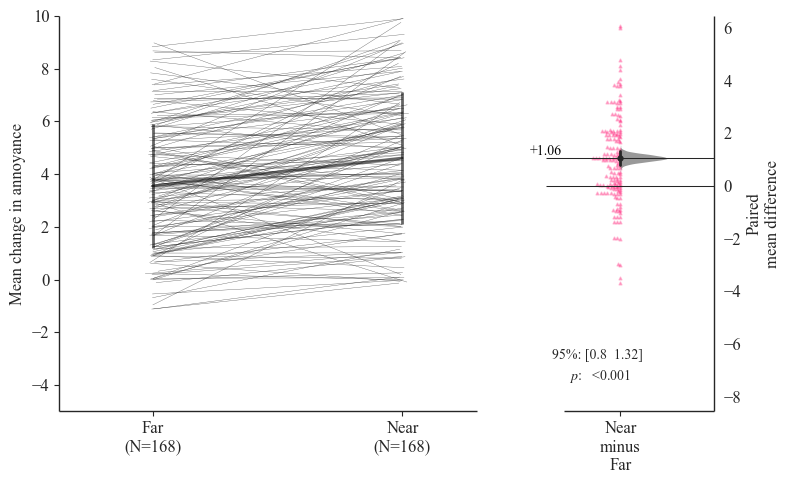

In [64]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False,
                                   raw_ylim=(-5, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [-1.75, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'Ambient env'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1,
                                                     'color': mycolours[2:]},
                                   contrast_ylim=(-5, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05,
                                                      'color': mycolours[2:]},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)

if saveplots:
    
    filename = "ProximityResidentialDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [65]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,Cohen's d,baseline,0.439011,95,0.323425,0.550074,0.0002,1.037860e-12,2599.0,6.685387e-13,-7.791853


#### Streetside square

In [68]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['AmbientEnv'] == "Streetside square")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# create dummy pairing ID for each participant to allow for paired analysis
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASProximity'].unique()) + 1, dtype=int),
                            len(data['UASProximity'].unique()), axis=0)

# remove any dummyID pairs of rows with at least one missing value
for dummyID in data['dummyID'].unique():
    if data[data['dummyID'] == dummyID].isnull().any(axis=None):
        data = data[data['dummyID'] != dummyID]

# remove unused categories from categorical columns
data['UASProximity'] = data['UASProximity'].cat.remove_unused_categories()

In [69]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Far", "Near"), x='UASProximity', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\dabest\plot_tools.py:2461: UserWarning: unique values in 'UASProximity' column in `data` and `palette` do not have the same length. Number of unique values is 1 while length of palette is 8. The assignment of the colors in the palette will be cycled.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,mean difference,baseline,0.784199,95,0.548883,1.037014,0.0002,2.345350e-08,3572.0,3.310214e-09,-6.249438


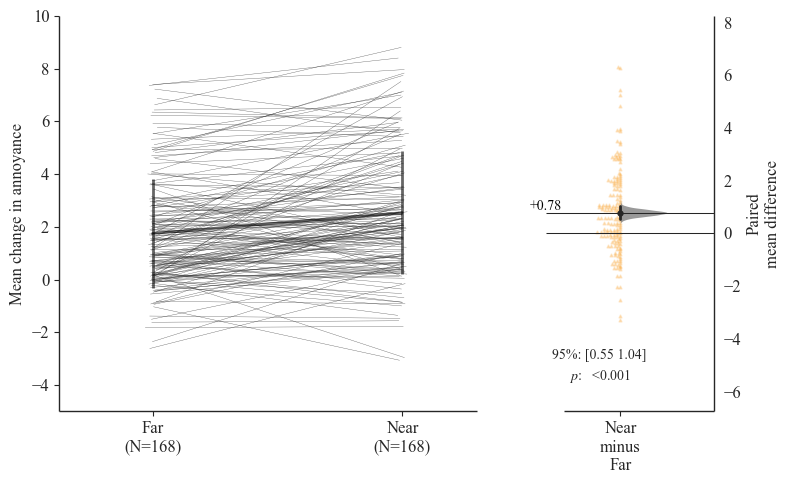

In [70]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False,
                                   raw_ylim=(-5, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [-1.75, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'Ambient env'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1,
                                                     'color': mycolours[4:]},
                                   contrast_ylim=(-5, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05,
                                                      'color': mycolours[4:]},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)

if saveplots:
    
    filename = "ProximityStreetSqDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [71]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,Cohen's d,baseline,0.356573,95,0.241682,0.474732,0.0002,2.345350e-08,3572.0,3.310214e-09,-6.249438


### by UAS type

#### H520

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest[(dataBySubjTest['ID'] != 49)
                       & (dataBySubjTest['UASEvents'] == 1)
                       & (dataBySubjTest['UASType'] == "H520")]
data = data.loc[:, ['ID', 'StimID', 'AmbientEnv', 'UASOperation', 'UASProximity', 'UASType', 'dAnnoyance']]
data.sort_values(by=['ID', 'StimID'], inplace=True)

# create dummy pairing ID for each participant to allow for paired analysis
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASProximity'].unique()) + 1, dtype=int),
                            len(data['UASProximity'].unique()), axis=0)

# remove any dummyID pairs of rows with at least one missing value
for dummyID in data['dummyID'].unique():
    if data[data['dummyID'] == dummyID].isnull().any(axis=None):
        data = data[data['dummyID'] != dummyID]

# remove unused categories from categorical columns
data['UASProximity'] = data['UASProximity'].cat.remove_unused_categories()

In [ ]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Far", "Near"), x='UASProximity', y='dAnnoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303,
                         ps_adjust=True)


c:\Users\m_lot\repos\refmap-psychoacoustics\.venv\Lib\site-packages\dabest\plot_tools.py:2461: UserWarning: unique values in 'UASProximity' column in `data` and `palette` do not have the same length. Number of unique values is 1 while length of palette is 8. The assignment of the colors in the palette will be cycled.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,mean difference,baseline,0.784199,95,0.548883,1.037014,0.0002,2.345350e-08,3572.0,3.310214e-09,-6.249438


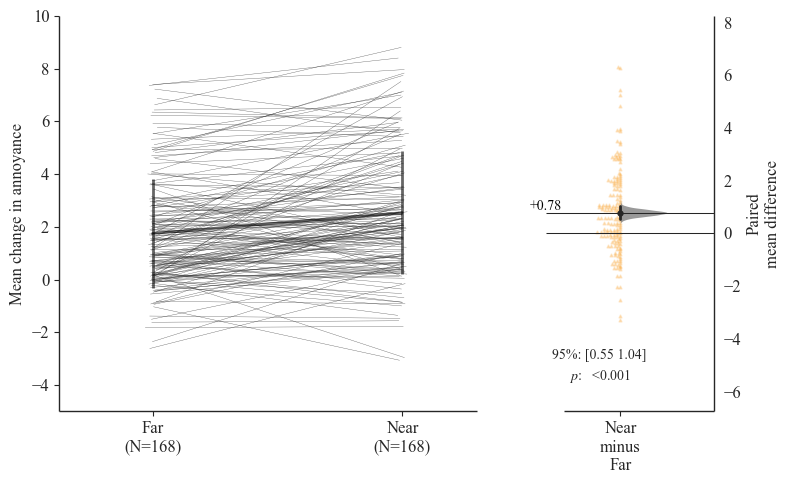

In [ ]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(8, 5))
dataMD = dataloadBL.mean_diff.plot(contrast_bars=False,
                                   raw_ylim=(-5, 10),
                                   raw_label="Mean change in annoyance",
                                   contrast_marker_size=3.5,
                                   show_baseline_ec=True,
                                   contrast_kwargs={'alpha': 0.8},
                                   legend_kwargs={'bbox_to_anchor': [-1.75, 1.3], 'fontsize': 11,
                                                  'ncol': 4, 'title': r'Ambient env'},
                                   delta_dot_kwargs={'size': 1, 'side': 'left',
                                                     'alpha': 0.25, 'zorder': 1,
                                                     'color': mycolours[4:]},
                                   contrast_ylim=(-5, 10),
                                   slopegraph_kwargs={'linewidth': 0.25,
                                                      'alpha': 0.8,
                                                      'jitter': 0.05,
                                                      'color': mycolours[4:]},
                                   ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference',
                                                'bca_low',
                                                'bca_high',
                                                'pvalue_permutation']].values

axs = dataMD.axes

# label results
ax.text(x=1.6, y=-3, s="95%: " + str(round_trad(diffs[0, 1:3], digits=2)), fontsize=10)
ax.text(x=1.67, y=-3.8, s=r"$p$:   " + display_round(diffs[0, 3], digits=3), fontsize=10)

if saveplots:
    
    filename = "ProximityStreetSqDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [ ]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Far,Near,168,168,Cohen's d,baseline,0.356573,95,0.241682,0.474732,0.0002,2.345350e-08,3572.0,3.310214e-09,-6.249438


## Save output data to file

In [135]:
if savedata:
    out.to_csv(os.path.join(outDataPath, "dabest_mean_diff.csv"))
    outd.to_csv(os.path.join(outDataPath, "dabest_cohens_d.csv"))